# Feynman-Kac Corrected LoRA Composition

Use ```diffusers_env.yaml``` virtual environment in the root folder.

This is the experiment of Custom SDXL Sampling Loop with FKC (Feynman-Kac Correction)
Implements score fusion of two LoRA adapters but also calculates importance weighting based on Proposition 3.1 (Classifier-Free Guidance + FKC).

Mathematical Formulation:
- Drift (Mixed Score): dx_t = σ_t^2 * ((1-β) * ∇log q_t^1(x_t) + β * ∇log q_t^2(x_t)) * dt
- Weight Evolution: dw_t = (σ_t^2 / 2) * β(β-1) * ||∇log q_t^1(x_t) - ∇log q_t^2(x_t)||^2 * dt
- Score Relation: ∇log q_t(x_t) ≈ -ε_θ(x_t, t) / σ_t

Implementation Details:
1. Maintains K parallel trajectories (particles)
2. Tracks cumulative log-weights based on score divergence
3. Uses dual-pass inference (one for each LoRA adapter)
4. Applies CFG independently to both predictions
5. Steps with geometric average: (1-β) * noise_a + β * noise_b

In [2]:
import os
import torch
import torch.nn.functional as F
from diffusers import DiffusionPipeline, EulerAncestralDiscreteScheduler
from diffusers.utils import is_peft_available
from PIL import Image

/slurm-storage/shucli/.conda/envs/diffusers/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Setup and Configuration

In [11]:
import os
import torch
from diffusers.utils import is_peft_available

# --- STEP 1: Smart Path Detection ---
# This works in BOTH .py scripts and .ipynb notebooks
try:
    # If running as a script
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # If running in a notebook
    current_dir = os.getcwd()

print(f"📂 Working directory: {current_dir}")

# --- STEP 2: Load HF Token ---
token_file = os.path.join(current_dir, "HF_token.txt")
if os.path.exists(token_file):
    with open(token_file, "r") as f:
        os.environ["HF_TOKEN"] = f.read().strip()
else:
    # Alternative: check if already in environment (e.g., set via terminal)
    if not os.environ.get("HF_TOKEN"):
        print(f"❌ Looking for token at: {token_file}")
        raise ValueError("HF_TOKEN unset! Please ensure 'HF_token.txt' exists or export HF_TOKEN.")

print("✅ HF_TOKEN successfully loaded.")

# --- STEP 3: Setup Output Directory ---
output_dir = os.path.join(current_dir, "outputs")
os.makedirs(output_dir, exist_ok=True)

# --- STEP 4: Configuration Parameters ---
K = 4  
beta = 0.5  
guidance_scale = 7.5  
num_inference_steps = 50  
height = 1024
width = 1024



# Ensure PEFT
if not is_peft_available():
    raise RuntimeError("PEFT is required. Run: pip install peft")

📂 Working directory: /mnt/data/slurm-storage/shucli/PROJECT_FOLDER/diffusers/MY_EXPERIMENTS
✅ HF_TOKEN successfully loaded.


## 2. Full Model Pipeline Initialization

In [12]:
# Prompts and Adapters
prompt_a = "A japanese animation girl eating a hamburger, voxel style"
prompt_b = "A japanese animation girl eating a hamburger, sexy style"
prompt_c = "A japanese animation girl eating a hamburger, voxel and sexy style"
negative_prompt = "blurry, low quality, distorted"

adapter_name_a = "voxel"
adapter_name_b = "sexy"

In [14]:
print("\n" + "="*80)
print("INITIALIZING MODEL")
print("="*80)

# Load SDXL pipeline
pipeline = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    variant="fp16"
)

# GPU detection and device placement
gpu_name = torch.cuda.get_device_name(0).upper()
print(f"Detected GPU: {gpu_name}")

if "H100" in gpu_name:
    print("H100 detected: Using full-speed mode (pipeline.to('cuda'))")
    pipeline.to("cuda")
    device = "cuda"
elif "A10" in gpu_name or "3090" in gpu_name or "4090" in gpu_name:
    print("24GB-class GPU detected: Using balanced mode (enable_model_cpu_offload)")
    pipeline.enable_model_cpu_offload()
    device = "cuda"
else:
    print("Smaller/unknown GPU detected: Using conservative mode (enable_sequential_cpu_offload)")
    pipeline.enable_sequential_cpu_offload()
    device = "cuda" if torch.cuda.is_available() else "cpu"

# Load LoRA adapters
print(f"\nLoading LoRA adapter '{adapter_name_a}' from 'Fictiverse/Voxel_XL_Lora'...")
pipeline.load_lora_weights('Fictiverse/Voxel_XL_Lora', adapter_name=adapter_name_a)

print(f"Loading LoRA adapter '{adapter_name_b}' from 'ntc-ai/SDXL-LoRA-slider.sexy'...")
pipeline.load_lora_weights('ntc-ai/SDXL-LoRA-slider.sexy', adapter_name=adapter_name_b)

# Set scheduler
pipeline.scheduler = EulerAncestralDiscreteScheduler.from_config(pipeline.scheduler.config)
print("✅ Scheduler set to EulerAncestralDiscreteScheduler")


INITIALIZING MODEL


Loading pipeline components...: 100%|██████████| 7/7 [00:02<00:00,  2.86it/s]


Detected GPU: NVIDIA A10
24GB-class GPU detected: Using balanced mode (enable_model_cpu_offload)

Loading LoRA adapter 'voxel' from 'Fictiverse/Voxel_XL_Lora'...


Loading weights: 100%|██████████| 384/384 [00:00<00:00, 969.67it/s, Materializing param=text_model.encoder.layers.31.self_attn.v_proj.lora_B.voxel.weight]  


Loading LoRA adapter 'sexy' from 'ntc-ai/SDXL-LoRA-slider.sexy'...


/slurm-storage/shucli/.conda/envs/diffusers/lib/python3.11/site-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diff

✅ Scheduler set to EulerAncestralDiscreteScheduler


## 3. Pre-compute prompt embeddings using the Pipeline

In [37]:
print("\n" + "="*80)
print("PRE-COMPUTING PROMPT EMBEDDINGS")
print("="*80)


# Encode prompts for style A
print(f"Encoding prompt A: '{prompt_a}'")
pipeline.set_adapters([adapter_name_a], adapter_weights=[1.0])
(
    prompt_embeds_a_pos,
    negative_prompt_embeds_a,
    pooled_prompt_embeds_a,
    negative_pooled_prompt_embeds_a,
) = pipeline.encode_prompt(
    prompt=prompt_a,
    negative_prompt=negative_prompt,
    num_images_per_prompt=1,
    do_classifier_free_guidance=True,
    device=device,
)

# Encode prompts for style B
print(f"Encoding prompt B: '{prompt_b}'")
pipeline.set_adapters([adapter_name_b], adapter_weights=[1.0])
(
    prompt_embeds_b_pos,
    negative_prompt_embeds_b,
    pooled_prompt_embeds_b,
    negative_pooled_prompt_embeds_b,
) = pipeline.encode_prompt(
    prompt=prompt_b,
    negative_prompt=negative_prompt,
    num_images_per_prompt=1,
    do_classifier_free_guidance=True,
    device=device,
)


# Encode prompt C
print(f"Encoding prompt C: '{prompt_c}'")
pipeline.set_adapters([adapter_name_a, adapter_name_b], adapter_weights=[1.0, 1.0])
(
    prompt_embeds_c_pos,
    negative_prompt_embeds_c,
    pooled_prompt_embeds_c,
    negative_pooled_prompt_embeds_c,
) = pipeline.encode_prompt(
    prompt=prompt_c,
    negative_prompt=negative_prompt,
    num_images_per_prompt=1,
    do_classifier_free_guidance=True,
    device=device,
)


# Concatenate negative and positive embeddings for CFG (as done in SDXL pipeline)
# This matches the format expected by the UNet: [negative, positive]
prompt_embeds_a = torch.cat([negative_prompt_embeds_a, prompt_embeds_a_pos], dim=0)
prompt_embeds_b = torch.cat([negative_prompt_embeds_b, prompt_embeds_b_pos], dim=0)
prompt_embeds_c = torch.cat([negative_prompt_embeds_c, prompt_embeds_c_pos], dim=0)
add_text_embeds_a = torch.cat([negative_pooled_prompt_embeds_a, pooled_prompt_embeds_a], dim=0)
add_text_embeds_b = torch.cat([negative_pooled_prompt_embeds_b, pooled_prompt_embeds_b], dim=0)
add_text_embeds_c = torch.cat([negative_pooled_prompt_embeds_c, pooled_prompt_embeds_c], dim=0)


# Prepare time_ids (required for SDXL)
original_size = (height, width)
crops_coords_top_left = (0, 0)
target_size = (height, width)
add_time_ids = pipeline._get_add_time_ids(
    original_size=original_size,
    crops_coords_top_left=crops_coords_top_left,
    target_size=target_size,
    dtype=prompt_embeds_a.dtype,
    text_encoder_projection_dim=pipeline.text_encoder_2.config.projection_dim,
)
add_time_ids = add_time_ids.to(device)

# For CFG, we need to duplicate time_ids
add_time_ids_cfg = add_time_ids.repeat(2, 1)  # [2, 6] for uncond + cond

print(f"\n ✅ Prompt embeddings prepared: (For text prompt C shown. A and B are similar.)")
print(f"   - prompt_embeds_c_pos shape: {prompt_embeds_c_pos.shape}")
print(f"   - negative_prompt_embeds_c shape: {negative_prompt_embeds_c.shape}")
print(f"   - prompt_embeds_c shape (after concat): {prompt_embeds_c.shape} (concatenated: [neg, pos]) \n")
print(f"   - pooled_prompt_embeds_c shape: {pooled_prompt_embeds_c.shape}")
print(f"   - negative_pooled_prompt_embeds_c shape: {negative_pooled_prompt_embeds_c.shape}")
print(f"   - add_text_embeds_c shape (after concat): {add_text_embeds_c.shape} (concatenated: [neg, pos])")


PRE-COMPUTING PROMPT EMBEDDINGS
Encoding prompt A: 'A japanese animation girl eating a hamburger, voxel style'
Encoding prompt B: 'A japanese animation girl eating a hamburger, sexy style'
Encoding prompt C: 'A japanese animation girl eating a hamburger, voxel and sexy style'

 ✅ Prompt embeddings prepared: (For text prompt C shown. A and B are similar.)
   - prompt_embeds_c_pos shape: torch.Size([1, 77, 2048])
   - negative_prompt_embeds_c shape: torch.Size([1, 77, 2048])
   - prompt_embeds_c shape (after concat): torch.Size([2, 77, 2048]) (concatenated: [neg, pos]) 

   - pooled_prompt_embeds_c shape: torch.Size([1, 1280])
   - negative_pooled_prompt_embeds_c shape: torch.Size([1, 1280])
   - add_text_embeds_c shape (after concat): torch.Size([2, 1280]) (concatenated: [neg, pos])


## 4. Initialize Particle and Weights

In [16]:
print("\n" + "="*80)
print("INITIALIZING PARTICLES AND WEIGHTS")
print("="*80)

# Initialize latents for K particles
latent_shape = (K, 4, height // pipeline.vae_scale_factor, width // pipeline.vae_scale_factor)
generator = torch.Generator(device=device).manual_seed(42)


# Initialize particles and weights
def initialize_particles_and_weights(pipeline, device, generator, K=10, height=128, width=128):
        
    # Use pipeline's prepare_latents to get properly scaled initial noise
    latents = pipeline.prepare_latents(
    batch_size=K,
    num_channels_latents=4,
    height=height,
    width=width,
    dtype=prompt_embeds_a.dtype,
    device=device,
    generator=generator,
    latents=None)

    # Initialize log weights (cumulative importance weights)
    log_weights = torch.zeros(K, device=device, dtype=torch.float32)

    return latents, log_weights


latents, log_weights = initialize_particles_and_weights(pipeline, device, generator, K=10, height=128, width=128)

print(f"✅ Initialized {latents.shape[0]} particles:")
print(f"   - Latents shape: {latents.shape}")
print(f"   - Log weights: {log_weights}")


INITIALIZING PARTICLES AND WEIGHTS
✅ Initialized 10 particles:
   - Latents shape: torch.Size([10, 4, 16, 16])
   - Log weights: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')


## 5a. Setup Scheduler


In [17]:
print("\n" + "="*80)
print("SETTING UP SCHEDULER")
print("="*80)

pipeline.scheduler.set_timesteps(num_inference_steps, device=device)
timesteps = pipeline.scheduler.timesteps  # 浮点整数组，如[999, 888, 777, ..., 0]
sigmas = pipeline.scheduler.sigmas.to(device)

# Reset scheduler step index (important for proper state management)
pipeline.scheduler._step_index = None

print(f"✅ Scheduler configured:")
print(f"   - Number of steps: {num_inference_steps}")
print(f"   - Timesteps shape: {timesteps.shape}")
print(f"   - Sigmas shape: {sigmas.shape}")


SETTING UP SCHEDULER
✅ Scheduler configured:
   - Number of steps: 50
   - Timesteps shape: torch.Size([50])
   - Sigmas shape: torch.Size([51])


## 5b. Setup Single-step FKC method (memory-efficient, iterative)

One backward step for all K particles: 

Text prompt `add_text_embedc` is used. For each of the $K$ particles, we get LoRA A and LoRA B predictions (with CFG), mix them, update weight, then one `scheduler.step` with the stacked mixed output. UNet is always called with batch size 2 (CFG only) to avoid OOM.

In [45]:
def step_one_fkc(latents, 
                 log_weights, 
                 step_index, 
                 timesteps=timesteps, 
                 beta = 0.5, 
                 guidance_scale = 7.5, 
                 verbose=True):
    """
    Perform one FKC backward step for all K particles at time t = timesteps[step_index].
    
    For each particle: get score/v from LoRA A and LoRA B (with CFG), mix as (1-β)*v1 + β*v2,
    update importance weight, then step with scheduler once on the stacked mixed output.
    UNet is called with batch size 2 (CFG) per particle to minimize memory.
    
    Args:
        latents: [K, 4, H, W] current noisy latents at time t
        log_weights: [K] cumulative log-importance-weights (will be updated in-place)
        step_index: int, index into timesteps (0 .. num_inference_steps-1)
        verbose: whether to print step info
    
    Returns:
        latents_next: [K, 4, H, W] latents at t-dt
        log_weights: [K] updated log weights (same tensor, updated in-place)
    """
    # Get current timestep and sigma
    t = timesteps[step_index]
    sigma_idx = pipeline.scheduler.index_for_timestep(t)
    sigma_t = sigmas[sigma_idx].item() if isinstance(sigmas[sigma_idx], torch.Tensor) else sigmas[sigma_idx]
    if sigma_idx < len(sigmas) - 1:
        sigma_next = sigmas[sigma_idx + 1].item() if isinstance(sigmas[sigma_idx + 1], torch.Tensor) else sigmas[sigma_idx + 1]
        dt = abs(sigma_t - sigma_next)
    else:
        dt = abs(sigma_t)
    
    # CFG embeddings for batch size 2 (one particle: uncond + cond)
    # Already have prompt_embeds_a/b [2, seq, hid], add_text_embeds_a/b [2, pooled], add_time_ids_cfg [2, 6]
    mixed_list = []
    K = latents.shape[0]
    
    with torch.no_grad():
        for k in range(K):
            latent_k = latents[k : k + 1]  # 取出[1, 4, H, W]的一个latent image（一个当前particle）
            latent_cfg = latent_k.repeat(2, 1, 1, 1)  # 复制成[2, 4, H, W]，用于CFG
            latent_cfg = pipeline.scheduler.scale_model_input(latent_cfg, t) # 缩放latent_cfg， shape=[2, 4, H, W]
            # 确保与 UNet 同设备（cpu_offload 时 UNet 会迁到输入的设备）
            unet_device = "cuda" if torch.cuda.is_available() else "cpu"
            latent_cfg = latent_cfg.to(unet_device)
            # prompt_embeds_c = prompt_embeds_c.to(unet_device)
            # add_text_embeds_c = add_text_embeds_c.to(unet_device)
            # add_time_ids_cfg = add_time_ids_cfg.to(unet_device)

            # Recall: 
            # prompt_embeds_a/b/c(可选)  [2, seq=77, hid=2048] = [1, 77, 2048] + [1, 77, 2048] (for uncond + cond)
            # add_text_embeds_a/b/c(可选)  [2, hid=1280] = [1, 1280] + [1, 1280] (for uncond + cond)
            # 画布属性：add_time_ids_cfg [2, 6], [[1024, 1024, 0, 0, 1024, 1024][1024, 1024, 0, 0, 1024, 1024]] 值基本永远不改。
            added_cond_a = {"text_embeds": add_text_embeds_a, "time_ids": add_time_ids_cfg}  
            pipeline.set_adapters([adapter_name_a], adapter_weights=[1.0])
            out_a = pipeline.unet(
                latent_cfg, t, # [2, 4, H, W]的latent image
                encoder_hidden_states=prompt_embeds_a, # [2, seq=77, hid=2048] (un)cond text的token-wise embed
                added_cond_kwargs=added_cond_a, # {[2, 1280](un)cond text 的全局embed,  [2, 6]画布}
                return_dict=False,
            )[0] # [2, 4, H, W]
            pred_a_uncond, pred_a_text = out_a.chunk(2) 
            pred_a = pred_a_uncond + guidance_scale * (pred_a_text - pred_a_uncond) # [1, 4, H, W]
            del out_a, pred_a_uncond, pred_a_text
            # if torch.cuda.is_available():
            #     torch.cuda.empty_cache()
            
            added_cond_b = {"text_embeds": add_text_embeds_b, "time_ids": add_time_ids_cfg}
            pipeline.set_adapters([adapter_name_b], adapter_weights=[1.0])
            out_b = pipeline.unet(
                latent_cfg, t,
                encoder_hidden_states=prompt_embeds_b,
                added_cond_kwargs=added_cond_b,
                return_dict=False,
            )[0]
            pred_b_uncond, pred_b_text = out_b.chunk(2)
            pred_b = pred_b_uncond + guidance_scale * (pred_b_text - pred_b_uncond) # [1, 4, H, W]
            del out_b, pred_b_uncond, pred_b_text, latent_cfg
            # if torch.cuda.is_available():
            #     torch.cuda.empty_cache()

            # Combined predictions
            mixed_k = (1 - beta) * pred_a + beta * pred_b
            mixed_list.append(mixed_k)
            
            dist_sq_k = torch.sum((pred_a - pred_b) ** 2, dim=[1, 2, 3]).squeeze(0)
            ##############################################################################################################
            ##### I'm not sure whether need multiply sigma_t**2 here. By derivation don't need it. But not sure about EDM scheduler, so may consider adding it. #######
            weight_update_k = (0.5 * beta * (beta - 1) * dist_sq_k * dt).to(log_weights.dtype)
            ##############################################################################################################
            log_weights[k] = log_weights[k] + weight_update_k.item()
            
            del pred_a, pred_b, mixed_k, dist_sq_k, weight_update_k
            # if torch.cuda.is_available():
            #     torch.cuda.empty_cache()
        
        mixed = torch.cat(mixed_list, dim=0) # [K, 4, H, W]
        del mixed_list
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        pipeline.scheduler._step_index = sigma_idx
        latents_next = latents - dt * mixed
        # latents_next = pipeline.scheduler.step(mixed, t, latents, return_dict=False)[0]  # latents, mixed both [K, 4, H, W]
        del mixed
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    if verbose:
        print(f"Step {step_index + 1}/{len(timesteps)} t={t.item():.0f} σ_t={sigma_t:.4f} dt={dt:.4f} | log_weights {log_weights} | Latents shape: {latents_next.shape}")
    
    return latents_next, log_weights

## 5c. Decode Resulting Latent Method

In [29]:
def decode_and_plot_particles(latents, log_weights, pipeline, title_prefix="Particle"):
    """
    Args:
        latents: [K, 4, 128, 128] tensor
        pipeline: SDXL pipeline
    """
    # 1. 强制使用 FP32 以防止 VAE 溢出导致黑图 (CRITICAL STEP)
    # 这一步非常重要，解码完成后可以再转回 FP16 省显存
    original_vae_dtype = pipeline.vae.dtype
    pipeline.vae.to(dtype=torch.float32)
    
    # 确保 latents 与 VAE 同设备（cpu_offload 时 pipeline.device 是 cpu，decode 时 VAE 会迁到 cuda，输入须在 cuda）
    vae_device = "cuda" if torch.cuda.is_available() else "cpu"
    latents = latents.to(device=vae_device, dtype=torch.float32)
    
    K = latents.shape[0]
    print(f"Decoding {K} particles...")

    with torch.no_grad():
        # 2. 处理 Scaling 和 Shift (SDXL 标准流程)
        scaling_factor = pipeline.vae.config.scaling_factor
        shift_factor = getattr(pipeline.vae.config, "shift_factor", None)
        
        if shift_factor is not None:
            latents_to_decode = (latents / scaling_factor) + shift_factor
        else:
            latents_to_decode = latents / scaling_factor
            
        # 3. VAE Decode（每次 4 张，避免显存爆掉）
        # 输入: [K, 4, 128, 128] -> 输出: [K, 3, 1024, 1024]
        batch_size = 1
        decoded_list = []
        for start in range(0, K, batch_size):
            end = min(start + batch_size, K)
            chunk = latents_to_decode[start:end]
            out = pipeline.vae.decode(chunk, return_dict=False)[0]
            decoded_list.append(out)
        decoded = torch.cat(decoded_list, dim=0)
        
        # 4. 后处理 (Tensor -> List[PIL.Image])
        # image_processor 会自动把 [K, 3, H, W] 切分成 K 个 PIL 图像
        pil_images = pipeline.image_processor.postprocess(decoded, output_type="pil")

    # 恢复 VAE 精度 (可选)
    pipeline.vae.to(dtype=original_vae_dtype)

    # 5. 动态计算网格并绘图
    cols = 4  # 你想一行放几张图
    rows = math.ceil(K / cols)
    
    plt.figure(figsize=(4 * cols, 4 * rows)) # 调整画布大小
    
    for i, img in enumerate(pil_images):
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img)
        ax.axis("off")
        lw = log_weights[i].item() if hasattr(log_weights[i], "item") else float(log_weights[i])
        ax.set_title(f"{title_prefix} #{i}\nlog_w={lw:.3f}")
        
    plt.tight_layout()
    plt.show()
    
    return pil_images


## 6. Run FKC step-by-step (iterative)


In [23]:
import gc
import torch
import math
import matplotlib.pyplot as plt

In [17]:
# ### In case OOM, clear Cached Memory first ###
del latents, log_weights
gc.collect()
if torch.cuda.is_available():
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
##############################################

In [ ]:
# Generate K initial particles and zero log weights
latents, log_weights = initialize_particles_and_weights(pipeline, device, generator, K=10, height=1024, width=1024)
print(f'Prepared {latents.shape[0]} particles of shape {latents.shape[1:]}')

Prepared 10 particles of shape torch.Size([4, 128, 128])


In [62]:
# Iteratively backward and compute the weights...
for step_index in range(num_inference_steps):
    latents, log_weights = step_one_fkc(latents, log_weights, step_index, beta = 1, guidance_scale=7.5, verbose=True)
print("Done. latents shape:", latents.shape, "| log_weights:", log_weights.cpu().numpy())

Step 1/50 t=981 σ_t=13.1204 dt=1.4444 | log_weights tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0') | Latents shape: torch.Size([10, 4, 128, 128])
Step 2/50 t=961 σ_t=11.6761 dt=1.2510 | log_weights tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0') | Latents shape: torch.Size([10, 4, 128, 128])
Step 3/50 t=941 σ_t=10.4250 dt=1.0870 | log_weights tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0') | Latents shape: torch.Size([10, 4, 128, 128])
Step 4/50 t=921 σ_t=9.3381 dt=0.9474 | log_weights tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0') | Latents shape: torch.Size([10, 4, 128, 128])
Step 5/50 t=901 σ_t=8.3907 dt=0.8283 | log_weights tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0') | Latents shape: torch.Size([10, 4, 128, 128])
Step 6/50 t=881 σ_t=7.5624 dt=0.7264 | log_weights tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0') | Latents shape: torch.Size([10, 4, 128, 128])
Step 7/50 t=8

In [79]:
gc.collect()
torch.cuda.empty_cache()

Decoding 10 particles...


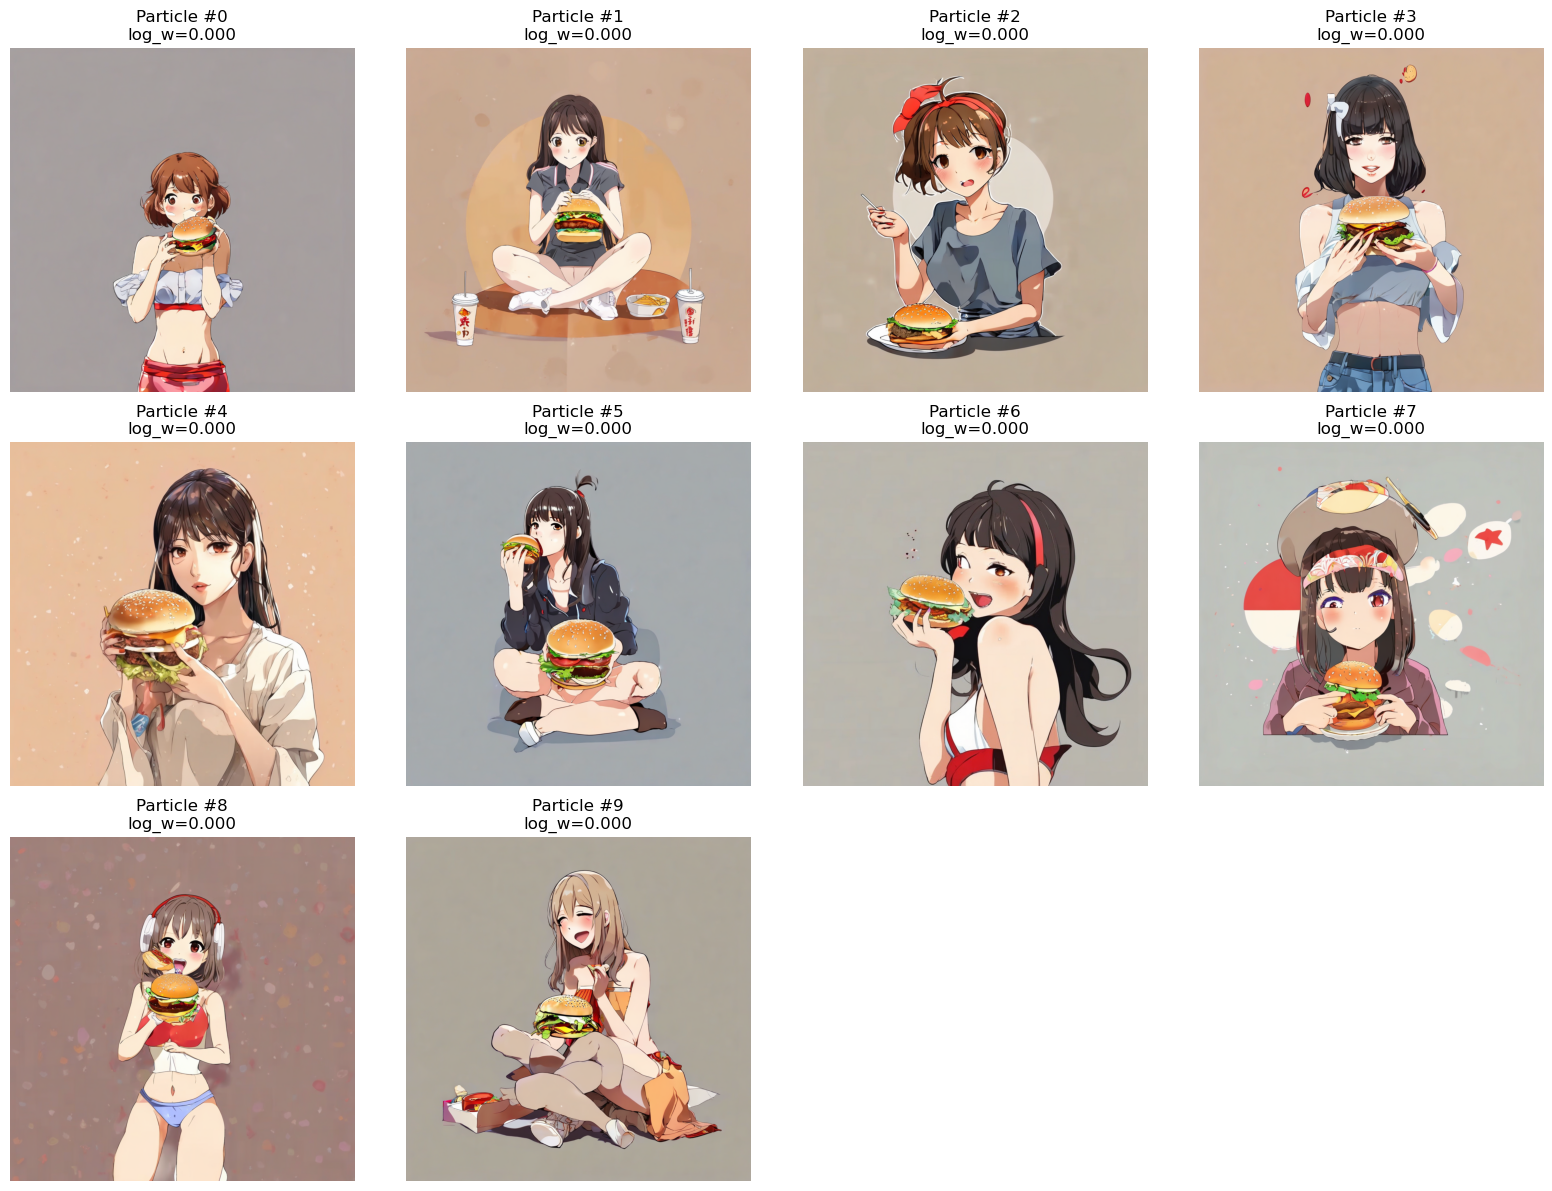

In [63]:
# ================= 使用方法 =================
# 假设 latents 形状是 [K, 4, 128, 128]
images = decode_and_plot_particles(latents, log_weights,pipeline)